In [2]:
import pandas as pd 
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('orders_clean.csv')
print(df.shape)

(9694, 22)


In [27]:
print(df['order_date_fixed'].dtype)

str


In [28]:
df['order_date_fixed'] = pd.to_datetime(df['order_date_fixed'])

In [29]:
print(df['order_date_fixed'].dtype)

datetime64[us]


In [30]:
snapshot_date = df['order_date_fixed'].max() + pd.Timedelta(days = 1)
print(snapshot_date)

2017-12-31 00:00:00


In [31]:
rfm = df.groupby('Customer ID').agg(
    Recency = ('order_date_fixed', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Order ID', 'nunique'),
    Monetary = ('Profit','sum')
).reset_index()

print(rfm.head())

  Customer ID  Recency  Frequency  Monetary
0    AA-10315      185          5 -362.8825
1    AA-10375       20          9  277.3824
2    AA-10480      260          4  432.0838
3    AA-10645       56          6  816.1441
4    AB-10015      416          3  129.3465


In [32]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels = [5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method= 'first'), 5, labels = [1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels = [1, 2, 3, 4, 5])

print(rfm.head())

  Customer ID  Recency  Frequency  Monetary R_score F_score M_score
0    AA-10315      185          5 -362.8825       2       2       1
1    AA-10375       20          9  277.3824       5       5       3
2    AA-10480      260          4  432.0838       1       1       4
3    AA-10645       56          6  816.1441       3       3       5
4    AB-10015      416          3  129.3465       1       1       2


In [33]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r>= 4 and f>=4 and m>= 4:
        return 'Champions'
    elif r>= 4 and f>=3:
        return 'Loyal Customers'
    elif r >=4 and f<=2:
        return 'New/Promising'
    elif r<=2 and f<=2 and m<=2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis = 1)
print(rfm['Segment'].value_counts())

Segment
Needs Attention    369
Loyal Customers    137
Lost               101
Champions           94
New/Promising       92
Name: count, dtype: int64


In [34]:
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending = False))

Segment
Needs Attention    156005.7679
Champions           87703.7373
New/Promising       28430.1282
Loyal Customers     19112.8963
Lost                -8394.7755
Name: Monetary, dtype: float64


In [35]:
print(rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending = False))

Segment
Champions          933.018482
Needs Attention    422.779859
New/Promising      309.023133
Loyal Customers    139.510192
Lost               -83.116589
Name: Monetary, dtype: float64


In [36]:
loyal_ids = rfm[rfm['Segment'] == 'Loyal Customers']['Customer ID']
loyal_orders = df[df['Customer ID'].isin(loyal_ids)]
print(loyal_orders.groupby('Category')['Profit'].mean().sort_values())

Category
Furniture          -7.590821
Office Supplies     5.302006
Technology         43.135970
Name: Profit, dtype: float64


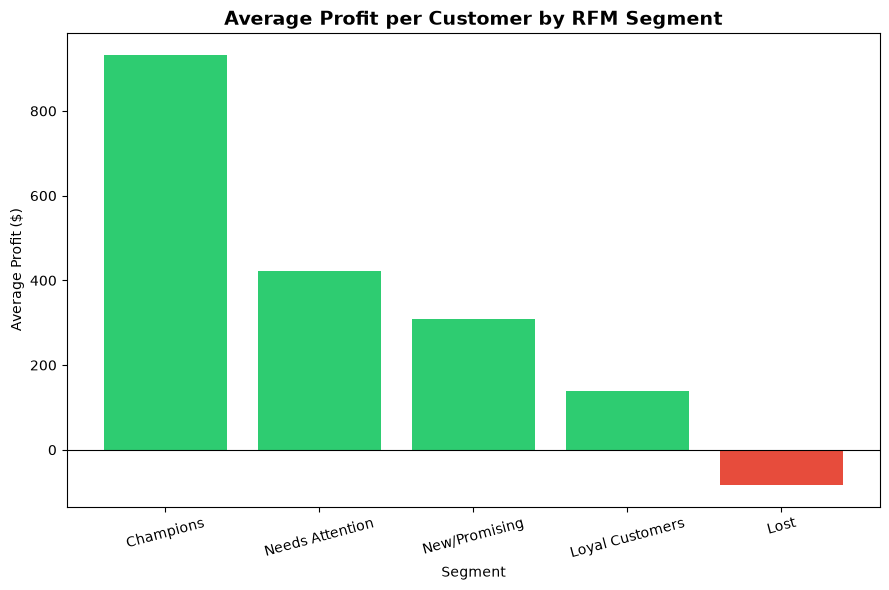

In [37]:
segment_avg = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending = False)

colors = ['#2ecc71' if val > 0 else '#e74c3c' for val in segment_avg]

plt.figure(figsize = (9, 6))
plt.bar(segment_avg.index, segment_avg.values, color = colors)
plt.axhline(0, color = 'black', linewidth = 0.8)
plt.title('Average Profit per Customer by RFM Segment', fontsize = 14, fontweight = 'bold')
plt.xlabel('Segment')
plt.ylabel('Average Profit ($)')
plt.xticks(rotation = 15)
plt.tight_layout()
plt.savefig('rfm_segment_profit.png', dpi = 150)
plt.show()

In [38]:
df.to_csv('orders_clean.csv', index=False)